# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Automobile Market Dataset](https://www.kaggle.com/datasets/ranaghulamnabi/automobile-market-dataset-vehicle-specification)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('automobile_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


## last Five row

In [4]:
df.tail()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,NaN,29506,161.0,NaN,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,NaN,NY,500
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474
5499,Chevrolet,Tahoe,2011,Petrol,Automatic,2.1,169929,168.0,158.0,3,1.0,NaN,Gray,SUV,AWD,NaN,MI,6193


## Shape of our dataset

In [5]:
df.shape

(5500, 18)

## List out all columns

In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size',
       'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History',
       'Service_History', 'Color', 'Body_Type', 'Drivetrain',
       'Fuel_Efficiency', 'Location', 'Selling_Price'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Make                 object
Model                object
Year                  int64
Fuel_Type            object
Transmission         object
Engine_Size         float64
Mileage               int64
Horsepower          float64
Torque              float64
Owners                int64
Accident_History    float64
Service_History      object
Color                object
Body_Type            object
Drivetrain           object
Fuel_Efficiency     float64
Location             object
Selling_Price         int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


## Check Null Value

In [9]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

## Get numerical and categorical columns

In [10]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

## Fill missing values in numerical columns with median

In [11]:
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

## Fill missing values in categorical columns with mode

In [12]:
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

## Verify that all missing values are handled

In [13]:
print(df.isnull().sum())

Make                0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Engine_Size         0
Mileage             0
Horsepower          0
Torque              0
Owners              0
Accident_History    0
Service_History     0
Color               0
Body_Type           0
Drivetrain          0
Fuel_Efficiency     0
Location            0
Selling_Price       0
dtype: int64


## Check Dupicate Value

In [14]:
df.duplicated().sum()

np.int64(0)

## Summary

In [15]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2014.494000,2.442855,114529.481636,196.602182,187.414545,2.464000,0.347818,33.865091,12319.873636
std,5.789745,0.776668,91858.943421,51.621268,52.499359,1.280022,0.476321,13.974959,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.100000,39112.000000,165.000000,156.000000,1.000000,0.000000,28.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,2.800000,172757.500000,223.000000,212.000000,3.000000,1.000000,36.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


# EDA

In [16]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

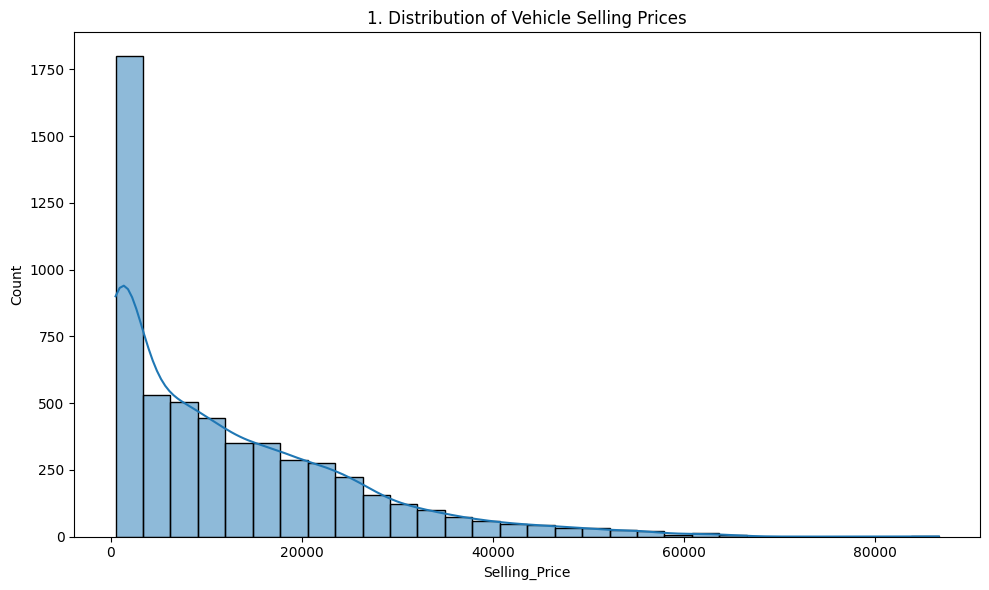

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Vehicle Selling Prices')
show_fig()
plot_no += 1

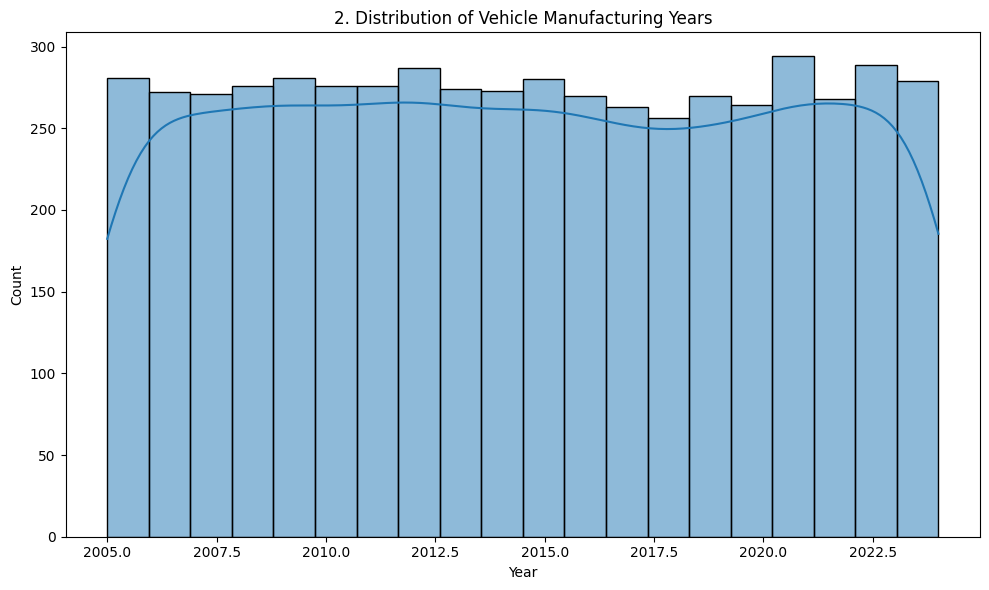

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Year'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Vehicle Manufacturing Years')
show_fig()
plot_no += 1

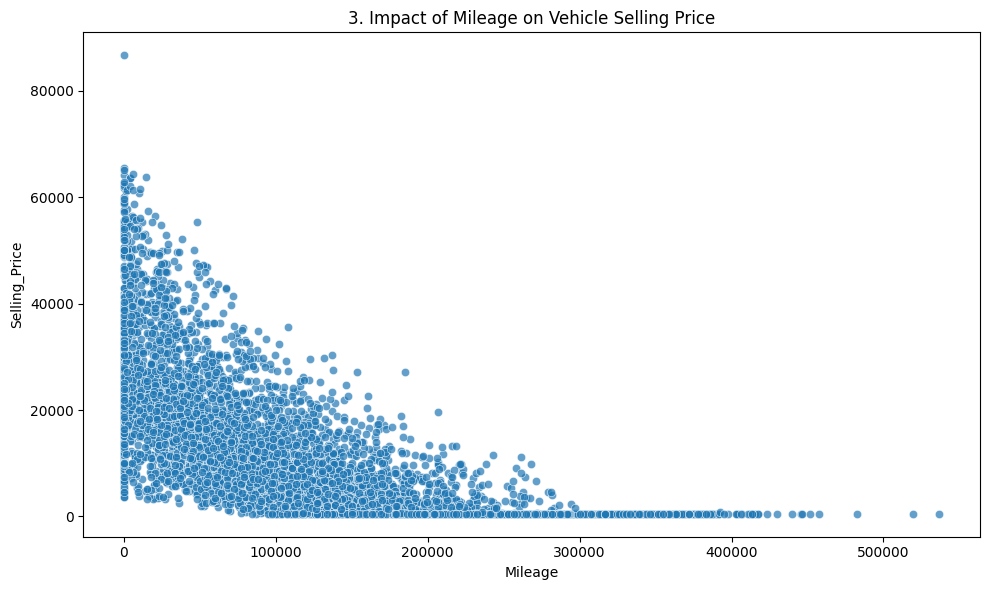

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Mileage', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Impact of Mileage on Vehicle Selling Price')
show_fig()
plot_no += 1

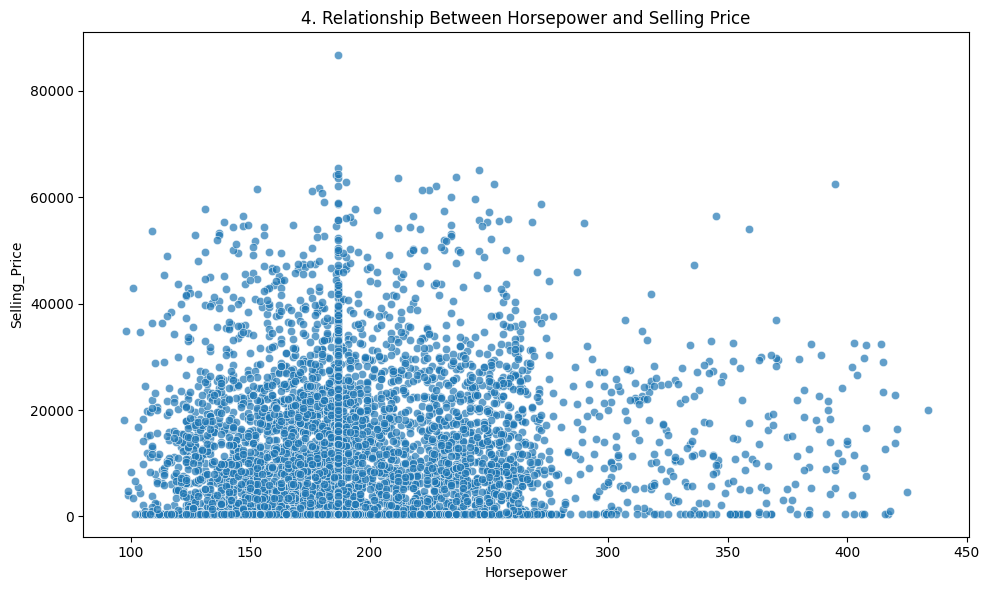

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Horsepower', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Horsepower and Selling Price')
show_fig()
plot_no += 1

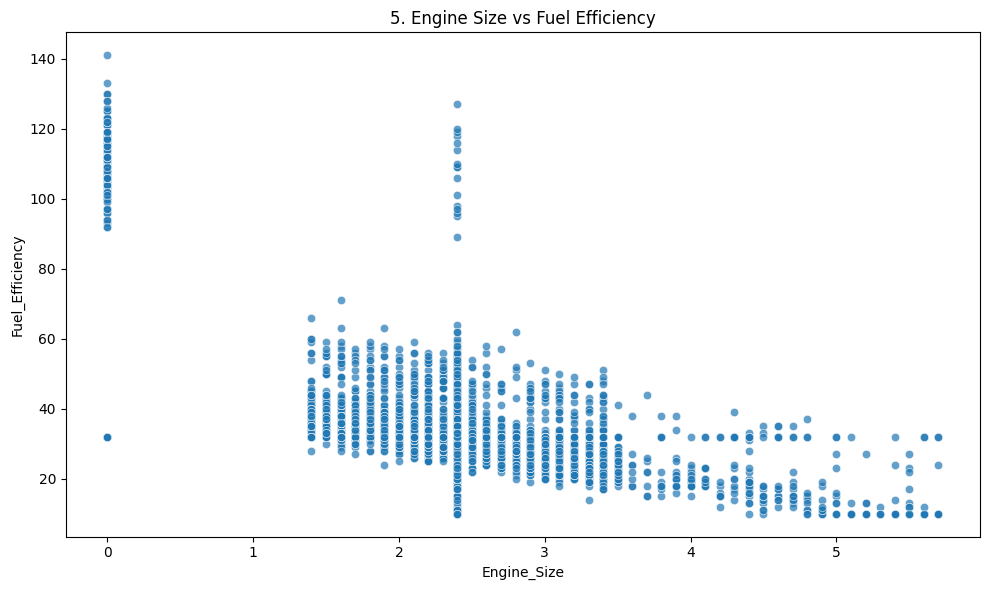

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Engine_Size', y='Fuel_Efficiency', alpha=0.7)
plt.title(f'{plot_no}. Engine Size vs Fuel Efficiency')
show_fig()
plot_no += 1

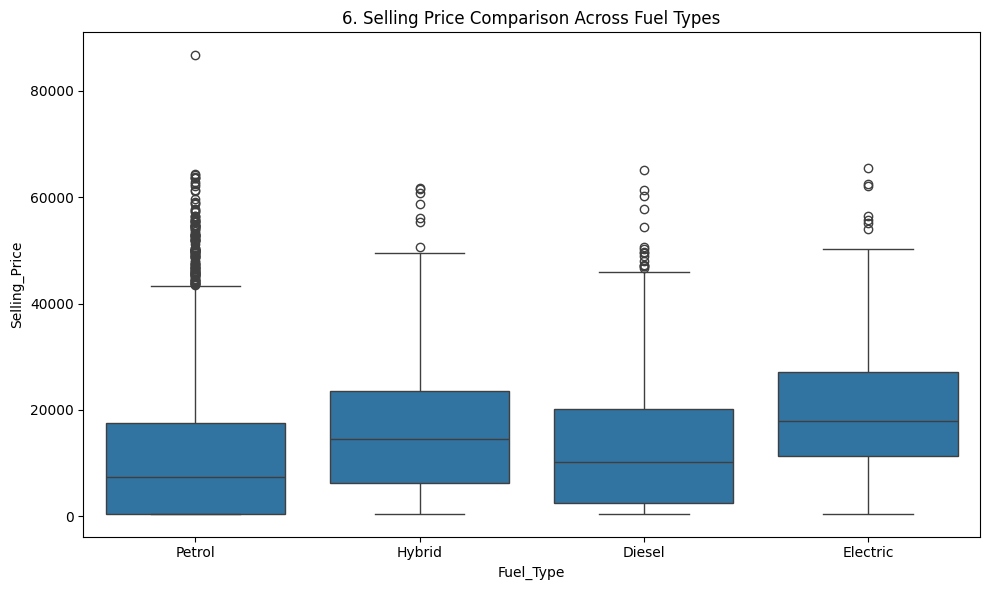

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price Comparison Across Fuel Types')
show_fig()
plot_no += 1

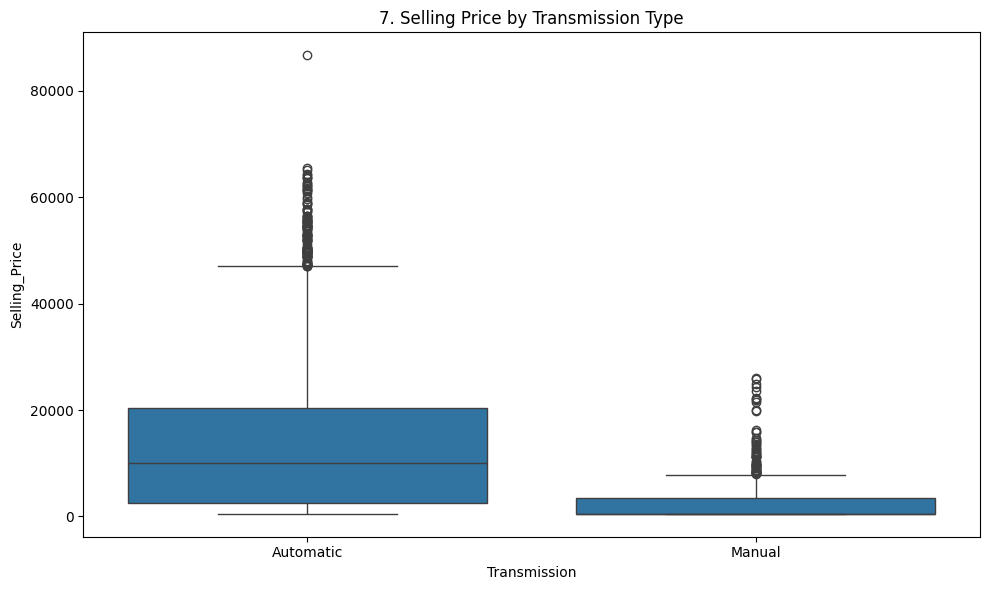

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price by Transmission Type')
show_fig()
plot_no += 1

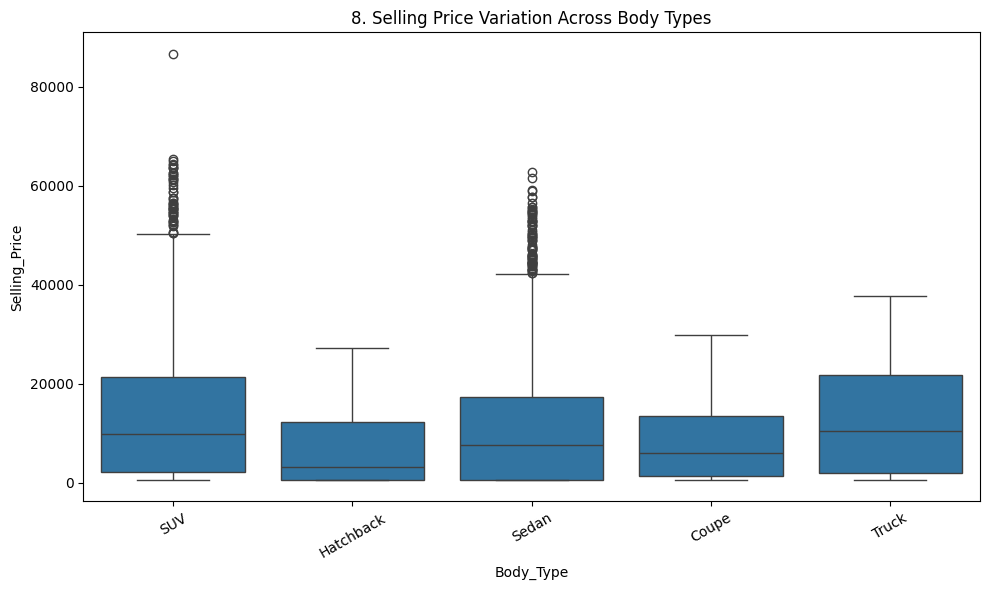

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Body_Type', y='Selling_Price')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Selling Price Variation Across Body Types')
show_fig()
plot_no += 1

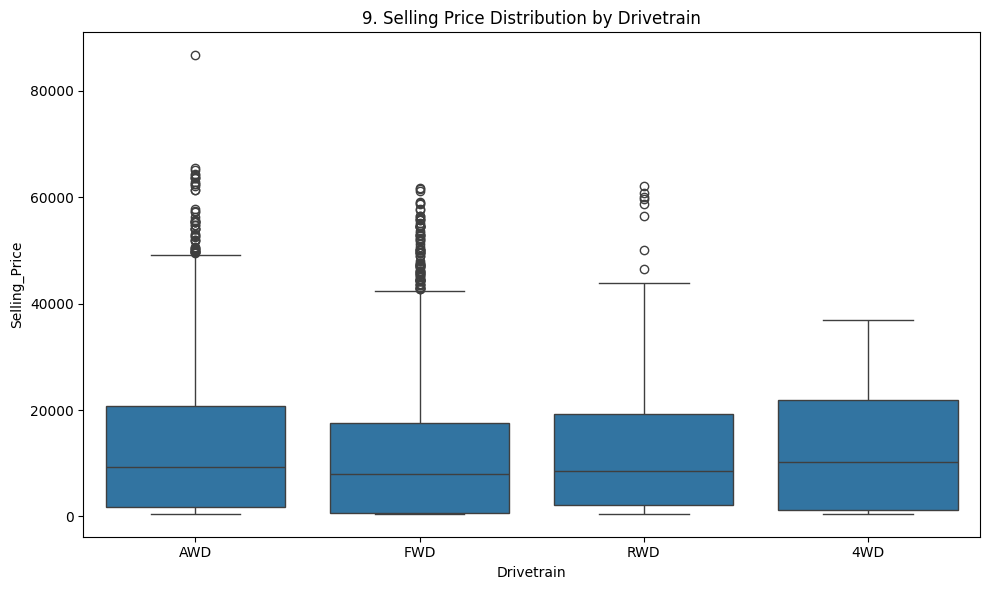

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Drivetrain', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price Distribution by Drivetrain')
show_fig()
plot_no += 1

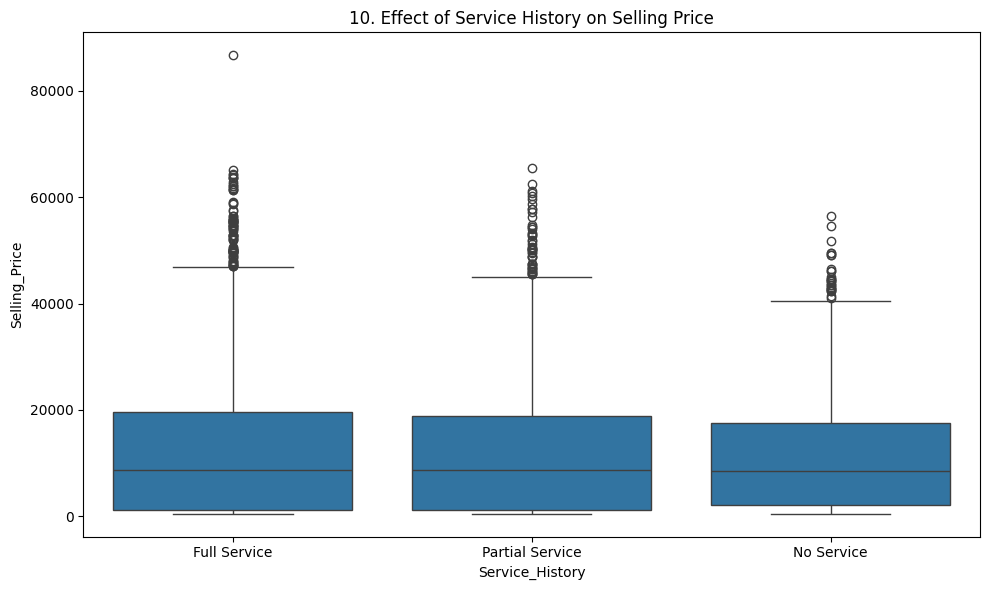

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Service_History', y='Selling_Price')
plt.title(f'{plot_no}. Effect of Service History on Selling Price')
show_fig()
plot_no += 1

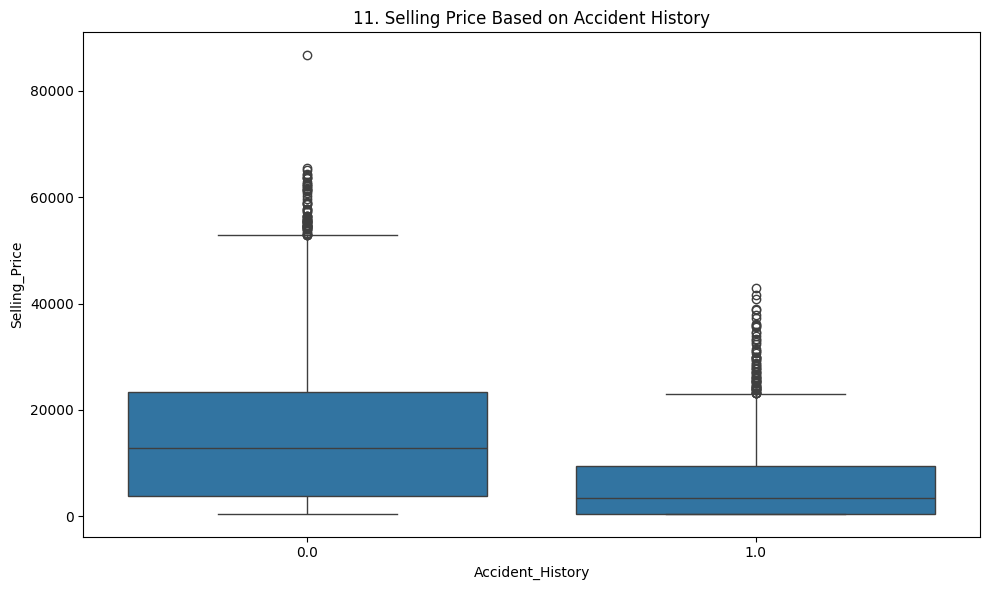

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Accident_History', y='Selling_Price')
plt.title(f'{plot_no}. Selling Price Based on Accident History')
show_fig()
plot_no += 1

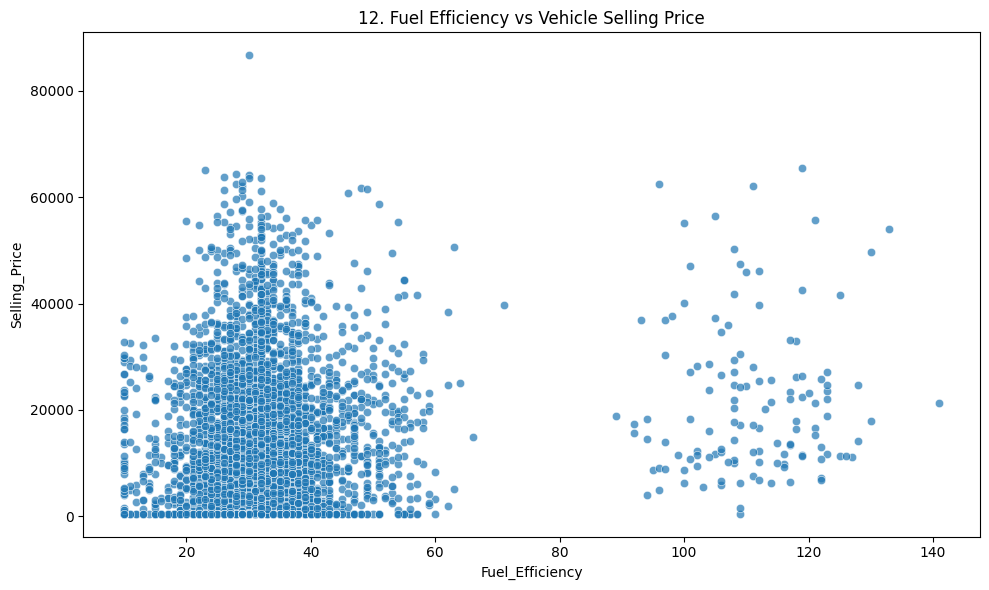

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fuel_Efficiency', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Fuel Efficiency vs Vehicle Selling Price')
show_fig()
plot_no += 1

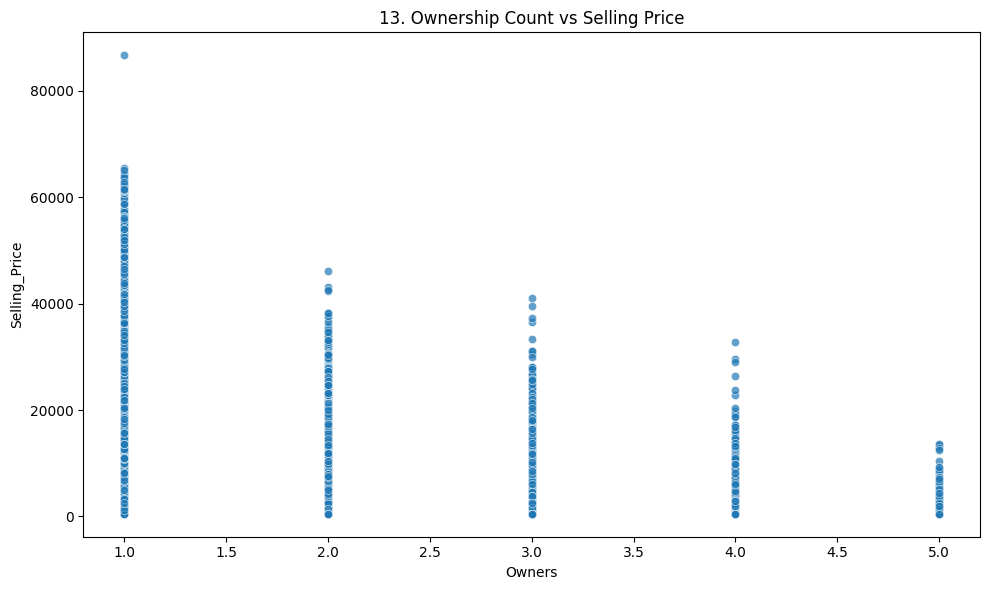

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Owners', y='Selling_Price', alpha=0.7)
plt.title(f'{plot_no}. Ownership Count vs Selling Price')
show_fig()
plot_no += 1

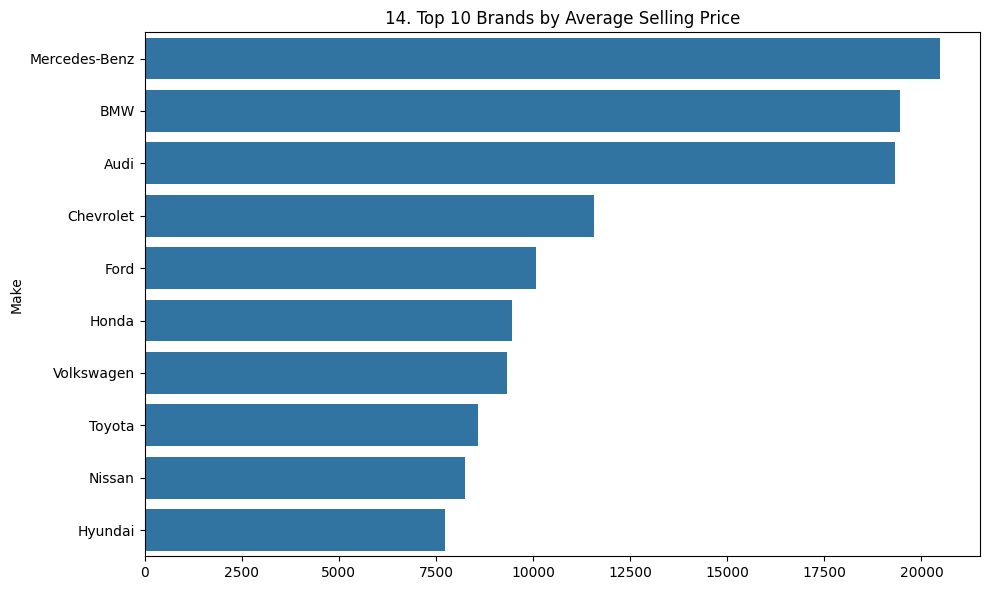

In [30]:
fig = plt.figure(figsize=(10,6))
top_make = df.groupby('Make')['Selling_Price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_make.values, y=top_make.index)
plt.title(f'{plot_no}. Top 10 Brands by Average Selling Price')
show_fig()
plot_no += 1

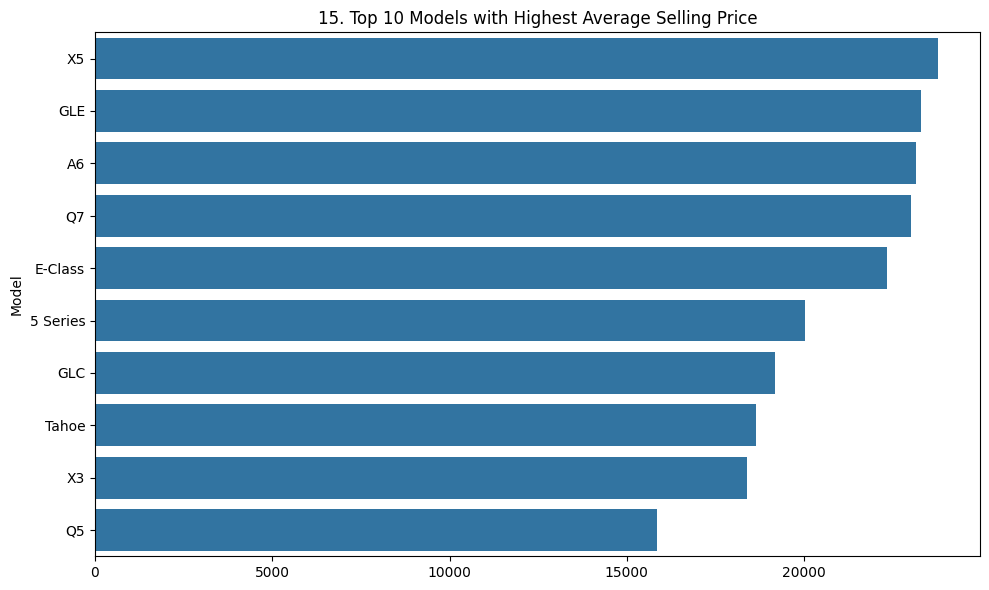

In [31]:
fig = plt.figure(figsize=(10,6))
top_model = df.groupby('Model')['Selling_Price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_model.values, y=top_model.index)
plt.title(f'{plot_no}. Top 10 Models with Highest Average Selling Price')
show_fig()
plot_no += 1

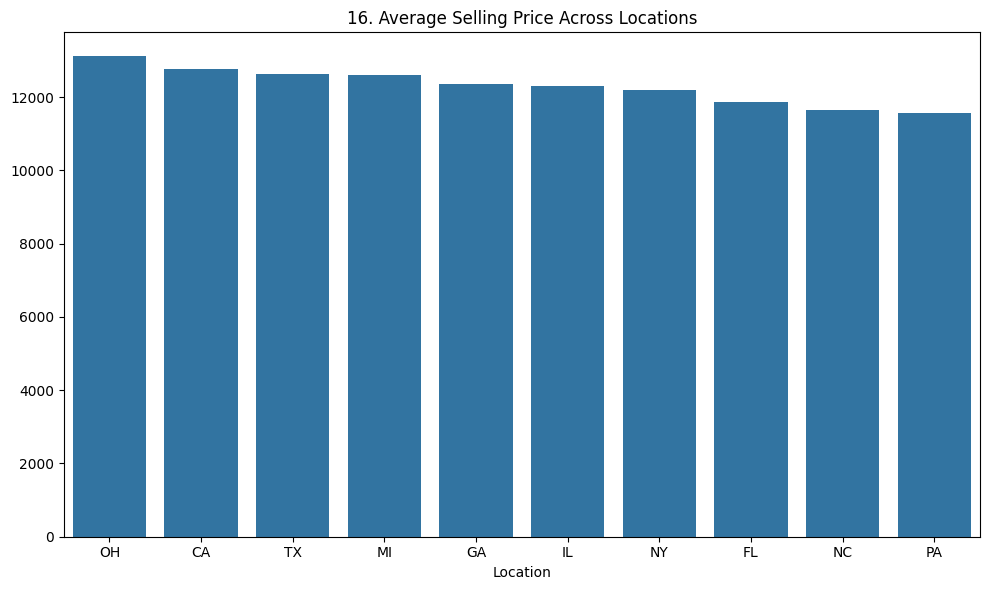

In [32]:
fig = plt.figure(figsize=(10,6))
top_location = df.groupby('Location')['Selling_Price'].mean().sort_values(ascending=False)
sns.barplot(x=top_location.index, y=top_location.values)
plt.title(f'{plot_no}. Average Selling Price Across Locations')
show_fig()
plot_no += 1

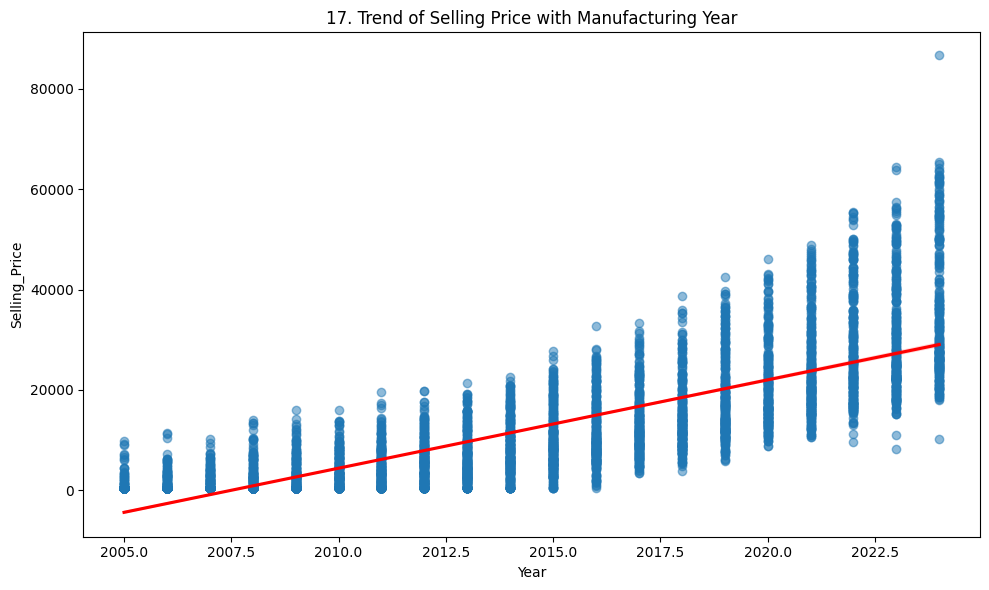

In [33]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Year', y='Selling_Price', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Trend of Selling Price with Manufacturing Year')
show_fig()
plot_no += 1

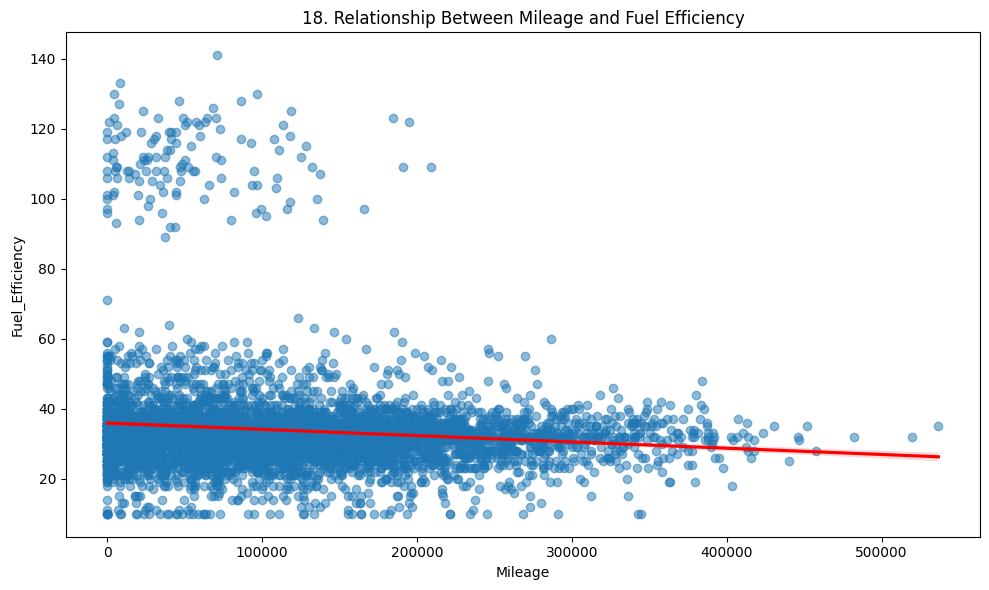

In [34]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Mileage', y='Fuel_Efficiency', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Relationship Between Mileage and Fuel Efficiency')
show_fig()
plot_no += 1

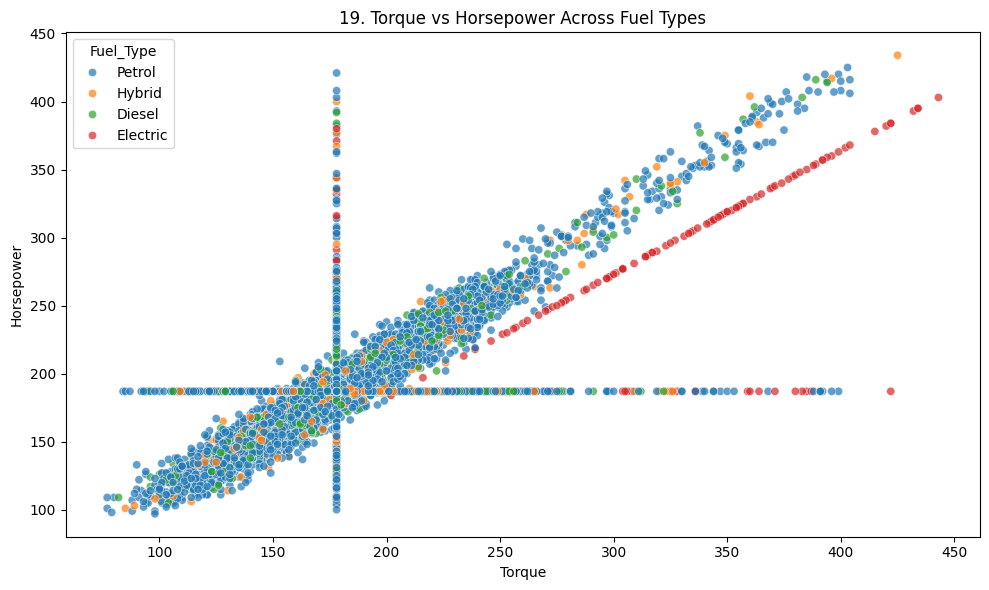

In [35]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Torque', y='Horsepower', hue='Fuel_Type', alpha=0.7)
plt.title(f'{plot_no}. Torque vs Horsepower Across Fuel Types')
show_fig()
plot_no += 1

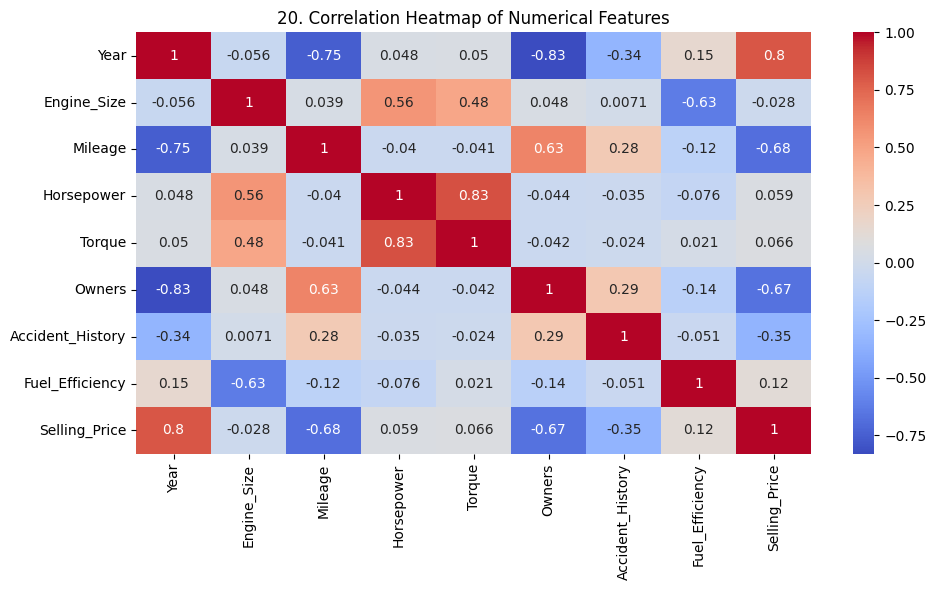

In [36]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [37]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

## Identify numerical and categorical columns

In [38]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

## Create preprocessing pipeline

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

## Split the dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Create Gradient Boosting pipeline

In [41]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.9,
        random_state=42
    ))
])

## Train the model

In [42]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict on test data

In [43]:
y_pred = model.predict(X_test)

## Print model performance

In [44]:
print("R² Score :", round(r2_score(y_test, y_pred), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE     :", round(mean_squared_error(y_test, y_pred) ** 0.5, 2))

R² Score : 0.9846
MAE      : 983.15
RMSE     : 1555.19


## Plot Actual vs Predicted

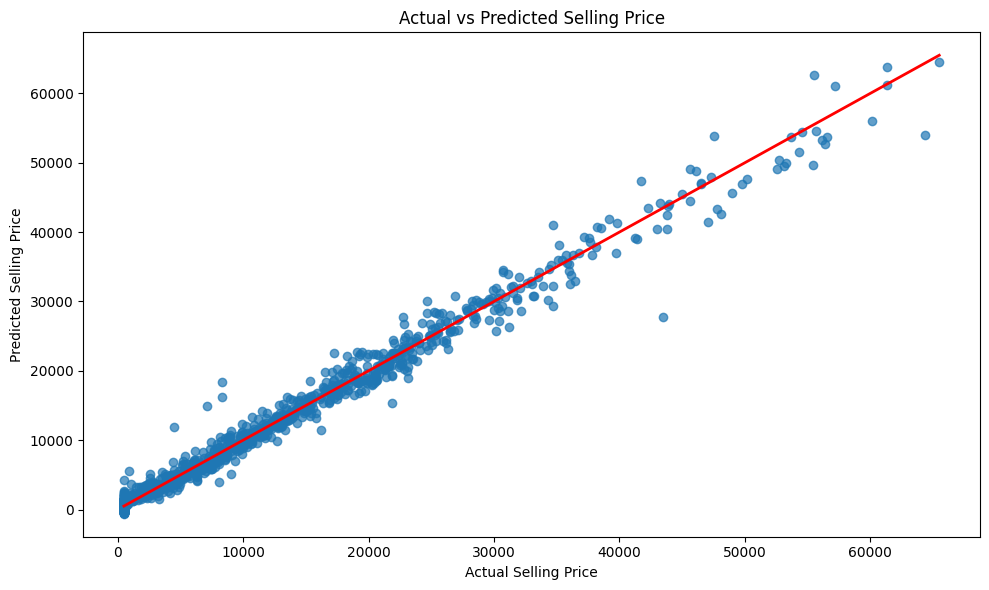

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.tight_layout()
plt.show()